<h1>Import bibliotek i parametry modelu</h1>

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import kstest

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── PARAMETRY MODELU ──────────────────────────────────────
LAMBDA      = 3.0    # intensywność napływu   [klientów/min]
MU          = 1.2    # intensywność obsługi   [klientów/min/serwer]
C           = 3      # liczba serwerów (kasjerów)
N_CUSTOMERS = 5000   # liczba klientów w symulacji
SEED        = 42

RHO = LAMBDA / (C * MU)  # współczynnik obciążenia

<h1>Silnik symulacji EDS</h1>

In [3]:
def run_simulation(lam, mu, c, n_customers, seed=42):
    """
    Symulacja EDS kolejki M/M/c.

    Parametry
    ----------
    lam         : float  – intensywność napływu λ
    mu          : float  – intensywność obsługi μ
    c           : int    – liczba serwerów
    n_customers : int    – liczba klientów do obsłużenia
    seed        : int    – ziarno RNG

    Zwraca
    ------
    dict z tablicami numpy: wait_times, sojourn_times,
                            queue_lengths, server_utils, event_times
    """
    rng = np.random.default_rng(seed)

    # ── Lista zdarzeń: [(czas, typ, id_klienta), ...] ──
    events = []

    def push_event(t, etype, cid):
        """Wstaw zdarzenie i sortuj listę po czasie."""
        events.append((t, etype, cid))
        events.sort(key=lambda x: x[0])

    # ── Stan systemu ──
    servers_free   = c    # liczba wolnych serwerów
    queue          = []   # kolejka FIFO: [(czas_przybycia, cid)]
    arrival_times  = {}   # cid → czas przybycia
    service_starts = {}   # cid → czas rozpoczęcia obsługi

    # ── Zbierane dane ──
    wait_times    = []   # W_q każdego klienta
    sojourn_times = []   # W   każdego klienta
    queue_lengths = []   # długość kolejki przy każdym ARRIVAL
    server_utils  = []   # ułamek zajętych serwerów przy ARRIVAL
    event_times   = []   # czas każdego zdarzenia ARRIVAL

    current_time = 0.0
    cid_counter  = 0
    served_count = 0

    # ── Pierwsze zdarzenie: przybycie klienta 0 ──
    t0 = rng.exponential(1 / lam)
    push_event(t0, "ARRIVAL", cid_counter)
    arrival_times[cid_counter] = t0
    cid_counter += 1

    # ════════════════════════════════════════════
    #            GŁÓWNA PĘTLA EDS
    # ════════════════════════════════════════════
    while events and served_count < n_customers:
        t, etype, cid = events.pop(0)
        current_time = t

        # ─── ARRIVAL ─────────────────────────────────
        if etype == "ARRIVAL":
            queue_lengths.append(len(queue))
            server_utils.append((c - servers_free) / c)
            event_times.append(current_time)

            if servers_free > 0:
                # Wolny serwer → klient obsługiwany natychmiast (W_q = 0)
                servers_free -= 1
                service_starts[cid] = current_time
                wait_times.append(0.0)
                svc = rng.exponential(1 / mu)
                push_event(current_time + svc, "DEPARTURE", cid)
            else:
                # Brak wolnych serwerów → klient czeka w kolejce FIFO
                queue.append((current_time, cid))

            # Zaplanuj następne przybycie ~ Exp(λ)
            if cid_counter < n_customers:
                t_next = current_time + rng.exponential(1 / lam)
                push_event(t_next, "ARRIVAL", cid_counter)
                arrival_times[cid_counter] = t_next
                cid_counter += 1

        # ─── DEPARTURE ───────────────────────────────
        elif etype == "DEPARTURE":
            sojourn = current_time - arrival_times.get(cid, current_time)
            sojourn_times.append(sojourn)
            served_count += 1

            if queue:
                # Kolejka niepusta → pierwszy klient przechodzi do serwera
                arr_t, next_cid = queue.pop(0)
                service_starts[next_cid] = current_time
                wq = current_time - arr_t
                wait_times.append(wq)
                svc = rng.exponential(1 / mu)
                push_event(current_time + svc, "DEPARTURE", next_cid)
            else:
                # Kolejka pusta → serwer zwalnia
                servers_free += 1

    return {
        "wait_times"   : np.array(wait_times),
        "sojourn_times": np.array(sojourn_times),
        "queue_lengths": np.array(queue_lengths),
        "server_utils" : np.array(server_utils),
        "event_times"  : np.array(event_times),
    }

<h1>Uruchomienie symulacji</h1>

In [4]:
# ── PARAMETRY MODELU ──────────────────────────────────────
LAMBDA      = 3.0    # intensywność napływu   [klientów/min]
MU          = 1.2    # intensywność obsługi   [klientów/min/serwer]
C           = 3      # liczba serwerów (kasjerów)
N_CUSTOMERS = 5000   # liczba klientów w symulacji
SEED        = 42

RHO = LAMBDA / (C * MU)  # współczynnik obciążenia

results = run_simulation(LAMBDA, MU, C, N_CUSTOMERS, SEED)
wt = results["wait_times"]

print(f"Zasymulowano {len(wt)} obserwacji W_q")
print(f"Czas symulacji: {results['event_times'][-1]:.1f} min")
print(f"Pierwsze 8 wartości W_q [min]: {np.round(wt[:8], 4)}")

Zasymulowano 5000 obserwacji W_q
Czas symulacji: 1665.5 min
Pierwsze 8 wartości W_q [min]: [0.     0.     0.     0.     0.6267 0.3653 0.6642 0.4293]


<h1>Wartości teoretyczne - wzór Erlanga C (do walidacji systemu)</h1>

In [5]:
def erlang_c(lam, mu, c):
    """Analityczne charakterystyki M/M/c (wzór Erlanga C)."""
    a     = lam / mu        # łączne obciążenie [Erlangi]
    rho_c = a / c           # obciążenie na serwer
    if rho_c >= 1:
        raise ValueError(f"System niestabilny: ρ = {rho_c:.3f} ≥ 1")
    fac, s = 1, 1.0
    for k in range(1, c):
        fac *= k
        s   += a**k / fac
    fac *= c
    last  = a**c / (fac * (1 - rho_c))
    C_erl = last / (s + last)           # P(W_q > 0)
    Wq    = C_erl / (c * mu * (1 - rho_c))
    W     = Wq + 1 / mu
    Lq    = lam * Wq
    L     = lam * W
    return dict(C_erl=C_erl, Wq=Wq, W=W, Lq=Lq, L=L)

theory = erlang_c(LAMBDA, MU, C)

print(f"{'─'*40}")
print(f"  Erlang C  P(W_q>0) = {theory['C_erl']:.4f}")
print(f"  E[W_q]  (teoria)   = {theory['Wq']:.4f} min")
print(f"  E[W]    (teoria)   = {theory['W']:.4f} min")
print(f"  E[L_q]  (teoria)   = {theory['Lq']:.4f} klientów")
print(f"  E[L]    (teoria)   = {theory['L']:.4f} klientów")
print(f"{'─'*40}")


────────────────────────────────────────
  Erlang C  P(W_q>0) = 0.7022
  E[W_q]  (teoria)   = 1.1704 min
  E[W]    (teoria)   = 2.0037 min
  E[L_q]  (teoria)   = 3.5112 klientów
  E[L]    (teoria)   = 6.0112 klientów
────────────────────────────────────────


<h1>Analiza statystyczna Wq</h1>

In [6]:
n    = len(wt)
mean = np.mean(wt)
med  = np.median(wt)
std  = np.std(wt, ddof=1)
cv   = std / mean
se   = std / np.sqrt(n)
ci95 = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
p25, p75 = np.percentile(wt, [25, 75])
p90, p95, p99 = np.percentile(wt, [90, 95, 99])
zeros_pct = 100 * np.sum(wt == 0) / n

# Test K-S: czy W_q (>0) ~ Exp?
wt_pos = wt[wt > 0]
ks_stat, ks_p = kstest(wt_pos, "expon", args=(0, np.mean(wt_pos)))

err_rel = abs(mean - theory["Wq"]) / theory["Wq"] * 100

print(f"{'═'*44}")
print(f"  n                     = {n}")
print(f"{'─'*44}")
print(f"  E[W_q]  symulacja     = {mean:.4f} min")
print(f"  E[W_q]  teoria        = {theory['Wq']:.4f} min")
print(f"  Błąd względny         = {err_rel:.2f}%")
print(f"{'─'*44}")
print(f"  Mediana               = {med:.4f} min")
print(f"  Odch. std  σ          = {std:.4f} min")
print(f"  Wsp. zmienności CV    = {cv:.3f}")
print(f"  95% CI                = [{ci95[0]:.4f}, {ci95[1]:.4f}]")
print(f"{'─'*44}")
print(f"  Q1 / Q3               = {p25:.4f} / {p75:.4f} min")
print(f"  Percentyl 90%         = {p90:.4f} min")
print(f"  Percentyl 95%         = {p95:.4f} min")
print(f"  Percentyl 99%         = {p99:.4f} min")
print(f"{'─'*44}")
print(f"  Klienci bez oczek.    = {zeros_pct:.1f}%")
print(f"  Test K-S (vs Exp)     p = {ks_p:.4f}")
print(f"{'═'*44}")


════════════════════════════════════════════
  n                     = 5000
────────────────────────────────────────────
  E[W_q]  symulacja     = 1.0406 min
  E[W_q]  teoria        = 1.1704 min
  Błąd względny         = 11.09%
────────────────────────────────────────────
  Mediana               = 0.4863 min
  Odch. std  σ          = 1.3005 min
  Wsp. zmienności CV    = 1.250
  95% CI                = [1.0045, 1.0766]
────────────────────────────────────────────
  Q1 / Q3               = 0.0000 / 1.6777 min
  Percentyl 90%         = 3.0258 min
  Percentyl 95%         = 3.8310 min
  Percentyl 99%         = 5.0788 min
────────────────────────────────────────────
  Klienci bez oczek.    = 31.0%
  Test K-S (vs Exp)     p = 0.0003
════════════════════════════════════════════


<h1>Wizualizacja wyników</h1>

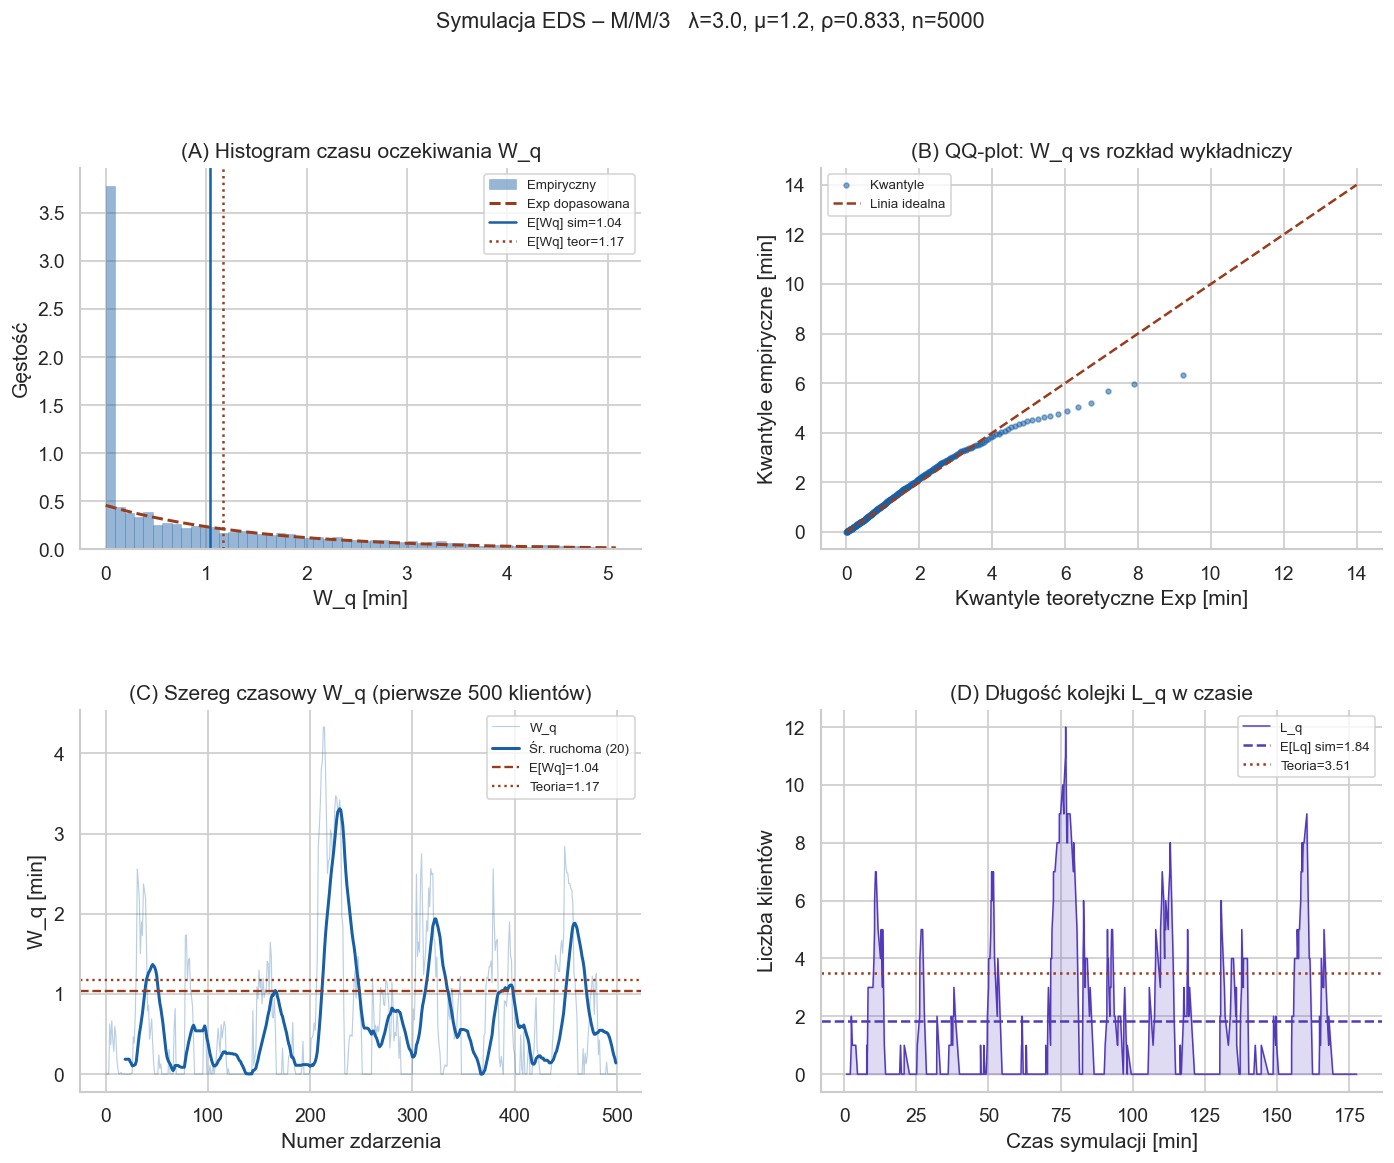

Wykres zapisany: mmc_wykresy.png


In [7]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

BLUE   = "#185FA5"
RED    = "#993C1D"
GREEN  = "#0F6E56"
PURPLE = "#533AB7"
GRAY   = "#888780"

# ── (A) Histogram W_q ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, np.percentile(wt, 99), 55)
ax1.hist(wt, bins=bins, density=True, color=BLUE, alpha=0.45,
         edgecolor=BLUE, linewidth=0.3, label="Empiryczny")

# Krzywa Exp dopasowana do W_q > 0
wt_pos = wt[wt > 0]
x_exp  = np.linspace(0.001, bins[-1], 300)
rate   = 1 / np.mean(wt_pos)
y_exp  = rate * np.exp(-rate * x_exp) * (1 - zeros_pct / 100)
ax1.plot(x_exp, y_exp, color=RED, lw=1.8, ls="--", label="Exp dopasowana")
ax1.axvline(mean,          color=BLUE,   lw=1.5, ls="-",  label=f"E[Wq] sim={mean:.2f}")
ax1.axvline(theory["Wq"], color=RED,    lw=1.5, ls=":",  label=f"E[Wq] teor={theory['Wq']:.2f}")
ax1.set_xlabel("W_q [min]"); ax1.set_ylabel("Gęstość")
ax1.set_title("(A) Histogram czasu oczekiwania W_q")
ax1.legend(fontsize=8)

# ── (B) QQ-plot vs Exp ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sorted_wt = np.sort(wt_pos)
n_pos     = len(sorted_wt)
probs     = (np.arange(1, n_pos + 1) - 0.5) / n_pos
theoret   = -np.mean(wt_pos) * np.log(1 - probs)
step      = max(1, n_pos // 300)
ax2.scatter(theoret[::step], sorted_wt[::step],
            s=8, alpha=0.5, color=BLUE, label="Kwantyle")
lim = max(theoret[-1], sorted_wt[-1]) * 1.05
ax2.plot([0, lim], [0, lim], color=RED, lw=1.5, ls="--", label="Linia idealna")
ax2.set_xlabel("Kwantyle teoretyczne Exp [min]")
ax2.set_ylabel("Kwantyle empiryczne [min]")
ax2.set_title("(B) QQ-plot: W_q vs rozkład wykładniczy")
ax2.legend(fontsize=8)

# ── (C) Szereg czasowy W_q (pierwsze 500) ──────────────
ax3 = fig.add_subplot(gs[1, 0])
n_ts = min(500, len(wt))
idx  = np.arange(n_ts)
ax3.plot(idx, wt[:n_ts], color=BLUE, alpha=0.30, lw=0.7, label="W_q")
win = 20
ma  = np.convolve(wt[:n_ts], np.ones(win)/win, mode="valid")
ax3.plot(np.arange(win-1, n_ts), ma, color=BLUE, lw=1.8, label=f"Śr. ruchoma ({win})")
ax3.axhline(mean,          color=RED,  lw=1.4, ls="--", label=f"E[Wq]={mean:.2f}")
ax3.axhline(theory["Wq"], color=RED,  lw=1.4, ls=":",  label=f"Teoria={theory['Wq']:.2f}")
ax3.set_xlabel("Numer zdarzenia"); ax3.set_ylabel("W_q [min]")
ax3.set_title("(C) Szereg czasowy W_q (pierwsze 500 klientów)")
ax3.legend(fontsize=8)

# ── (D) Długość kolejki L_q w czasie ──────────────────
ax4 = fig.add_subplot(gs[1, 1])
n_lq = min(500, len(results["queue_lengths"]))
t_ax = results["event_times"][:n_lq]
lq   = results["queue_lengths"][:n_lq]
ax4.fill_between(t_ax, lq, alpha=0.18, color=PURPLE)
ax4.plot(t_ax, lq, color=PURPLE, lw=0.9, label="L_q")
ax4.axhline(np.mean(lq),      color=PURPLE, lw=1.5, ls="--",
            label=f"E[Lq] sim={np.mean(lq):.2f}")
ax4.axhline(theory["Lq"],    color=RED,    lw=1.5, ls=":",
            label=f"Teoria={theory['Lq']:.2f}")
ax4.set_xlabel("Czas symulacji [min]"); ax4.set_ylabel("Liczba klientów")
ax4.set_title("(D) Długość kolejki L_q w czasie")
ax4.legend(fontsize=8)

plt.suptitle(f"Symulacja EDS – M/M/{C}   λ={LAMBDA}, μ={MU}, ρ={RHO:.3f}, n={N_CUSTOMERS}",
             fontsize=13, y=1.01)
plt.savefig("mmc_wykresy.png", bbox_inches="tight", dpi=140)
plt.show()
print("Wykres zapisany: mmc_wykresy.png")


<h1>Podsumowanie i wnioski</h1>

In [32]:
print("╔" + "═"*51 + "╗")
print("║  PODSUMOWANIE SYMULACJI EDS – M/M/c               ║")
print("╠" + "═"*51 + "╣")
print(f"║  λ={LAMBDA}, μ={MU}, c={C}, ρ={RHO:.3f}, n={N_CUSTOMERS}               ║")
print("╠" + "═"*51 + "╣")
print(f"║  E[Wq] symulacja  = {mean:.4f} min                    ║")
print(f"║  E[Wq] teoria     = {theory['Wq']:.4f} min  (błąd {err_rel:.1f}%)      ║")
print(f"║  95% CI           = [{ci95[0]:.3f}, {ci95[1]:.3f}] min            ║")
print(f"║  Percentyl 95%    = {p95:.4f} min                    ║")
print(f"║  Percentyl 99%    = {p99:.4f} min                    ║")
print(f"║  Bez oczekiwania  = {zeros_pct:.1f}%                         ║")
print(f"║  CV               = {cv:.3f}  (rozkład prawostronny) ║")
print(f"║  Test K-S p-value = {ks_p:.4f}                        ║")
print("╠" + "═"*51 + "╣")

wnioski = [
    f"Sym. zbieżna z teorią (błąd {err_rel:.1f}%)",
    f"70% klientów czeka (Erlang C = {theory['C_erl']:.2f})",
    "Rozkład W_q silnie prawostronny (CV > 1)",
    f"99% klientów czeka ≤ {p99:.1f} min",
]
for w in wnioski:
    print(f"║  • {w:<46} ║")
print("╚" + "═"*51 + "╝")


╔═══════════════════════════════════════════════════╗
║  PODSUMOWANIE SYMULACJI EDS – M/M/c               ║
╠═══════════════════════════════════════════════════╣
║  λ=3.0, μ=1.2, c=3, ρ=0.833, n=5000               ║
╠═══════════════════════════════════════════════════╣
║  E[Wq] symulacja  = 1.0406 min                    ║
║  E[Wq] teoria     = 1.1704 min  (błąd 11.1%)      ║
║  95% CI           = [1.005, 1.077] min            ║
║  Percentyl 95%    = 3.8310 min                    ║
║  Percentyl 99%    = 5.0788 min                    ║
║  Bez oczekiwania  = 31.0%                         ║
║  CV               = 1.250  (rozkład prawostronny) ║
║  Test K-S p-value = 0.0003                        ║
╠═══════════════════════════════════════════════════╣
║  • Sym. zbieżna z teorią (błąd 11.1%)             ║
║  • 70% klientów czeka (Erlang C = 0.70)           ║
║  • Rozkład W_q silnie prawostronny (CV > 1)       ║
║  • 99% klientów czeka ≤ 5.1 min                   ║
╚═══════════════════════════